In [1]:
import cv2
import numpy as np
import pandas as pd
import io
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
import math
import random
from scipy import stats
from typing import Literal, List, Tuple
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models.inception import Inception_V3_Weights
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

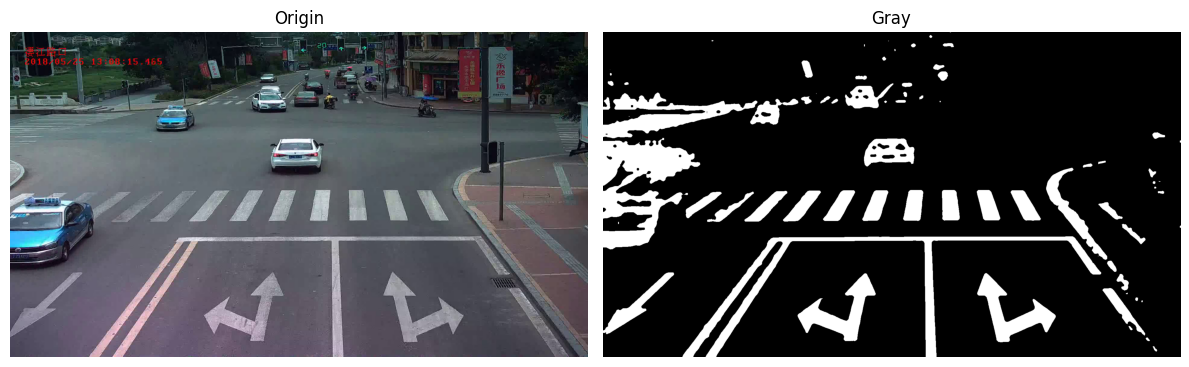

In [2]:
image_handler = r'E:\pandownload1\ML\Police\Project\source\lane.jpg'
rgb_image = None
image = None
with open(image_handler, 'rb') as img:
    rgb_image = Image.open(io.BytesIO(img.read()))
    image = cv2.cvtColor(np.array(rgb_image, dtype=np.uint8), cv2.COLOR_RGB2BGR)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
equalized_gray = cv2.equalizeHist(gray)

hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv_img)
equalized_v = cv2.equalizeHist(v)
equalized_hsv = cv2.merge((h, s, equalized_v))
equalized_color = cv2.cvtColor(equalized_hsv, cv2.COLOR_HSV2BGR)

kernel = np.ones((3,3), np.uint8)

proved_gray = cv2.cvtColor(equalized_color, cv2.COLOR_BGR2GRAY)
_, threshold = cv2.threshold(gray, 130, 255, cv2.THRESH_BINARY)
dilated_edges = cv2.dilate(threshold, kernel)
dilated_edges = cv2.dilate(dilated_edges, kernel)
dilated_edges = cv2.dilate(dilated_edges, kernel)
eroded_edges = cv2.erode(dilated_edges, kernel)
eroded_edges = cv2.erode(eroded_edges, kernel)
threshold = cv2.erode(eroded_edges, kernel)
threshold = cv2.medianBlur(threshold, 13)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(rgb_image)
ax1.set_title('Origin')
ax1.axis('off')
ax2.imshow(threshold, cmap='gray')
ax2.set_title('Gray')
ax2.axis('off')
plt.tight_layout()
plt.show()

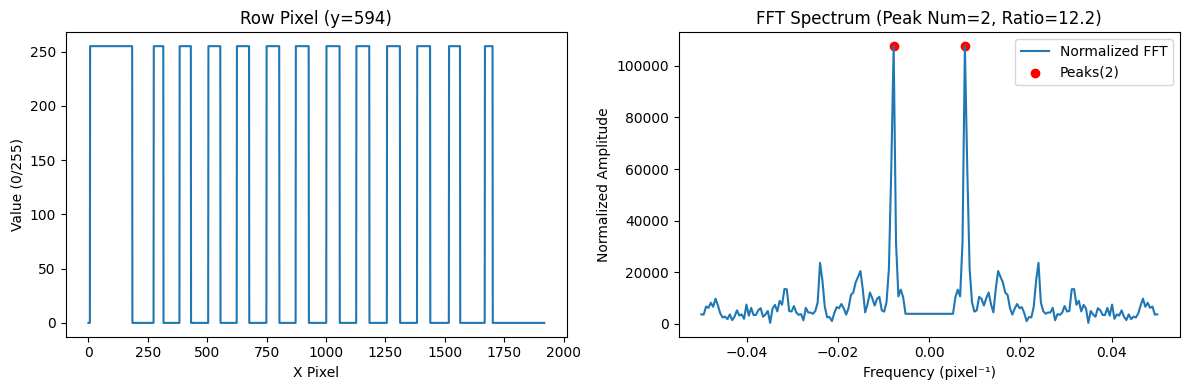

,是否为斑马线,主频率,间距,归一化峰值比,峰值数量
0,True,-0.007812 像素⁻¹,-128.0 像素,12.2,2


In [3]:
def row_fft_detect_optimized(row_data, peak_ratio_thresh=8.0, 
                             min_freq=0.005, max_freq=0.05, max_peak_num=3, ax=None):
    """
    对二值化行数据做FFT，检测周期性峰值（含峰数量过滤）
    """
    row_no_dc = row_data - np.mean(row_data)
    
    f = np.fft.fft(row_no_dc)
    f_shift = np.fft.fftshift(f)
    f_amp = np.abs(f_shift)
    freq_x = np.fft.fftfreq(len(row_data))
    freq_x = np.fft.fftshift(freq_x)
    
    freq_mask = (np.abs(freq_x) >= min_freq) & (np.abs(freq_x) <= max_freq)
    valid_amp = f_amp[freq_mask]
    valid_freq = freq_x[freq_mask]
    
    if len(valid_amp) == 0 or np.mean(valid_amp) < 1e-6:
        return False, 0, 0, 0
    
    max_amp = np.max(valid_amp)
    mean_amp = np.mean(valid_amp)
    peak_ratio = max_amp / mean_amp
    
    peaks, _ = find_peaks(valid_amp, height=0.5*max_amp, distance=5)
    peak_num = len(peaks)
    
    is_zebra_row = (peak_ratio > peak_ratio_thresh) and (peak_num <= max_peak_num)
    main_freq = valid_freq[peaks[0]] if peak_num > 0 else 0

    if ax is not None:
        ax.plot(valid_freq, valid_amp, label='Normalized FFT')
        ax.scatter(valid_freq[peaks], valid_amp[peaks], color='red', label=f'Peaks({peak_num})')
        ax.set_title(f'FFT Spectrum (Peak Num={peak_num}, Ratio={peak_ratio:.1f})')
        ax.set_xlabel('Frequency (pixel⁻¹)')
        ax.set_ylabel('Normalized Amplitude')
        ax.legend()
    
    return is_zebra_row, main_freq, peak_ratio, peak_num

height, width = image.shape[:2]

line = threshold[int(height * 0.55), :]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(line)
ax1.set_title(f'Row Pixel (y={int(height*0.55)})')
ax1.set_xlabel('X Pixel')
ax1.set_ylabel('Value (0/255)')

is_zebra, main_freq, peak_ratio, peak_num = row_fft_detect_optimized(
    line,
    peak_ratio_thresh=8.0,
    min_freq=0.005,
    max_freq=0.05,
    max_peak_num=3,
    ax=ax2
)

plt.tight_layout()
plt.show()

pd.DataFrame({
    '是否为斑马线': [is_zebra],
    '主频率': [f"{main_freq:.6f} 像素⁻¹"],
    '间距': [f'{1/main_freq:.1f} 像素'],
    '归一化峰值比': [f"{peak_ratio:.1f}"],
    '峰值数量': [peak_num]
})

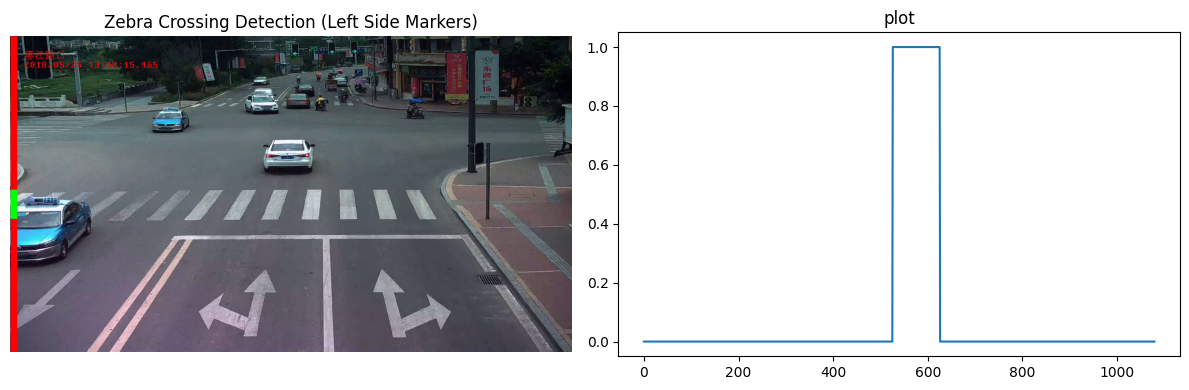

总计检测到 100 行斑马线

斑马线行详情：


,行号,是否为斑马线,主频率,间距,归一化峰值比,峰值数量
526,526,True,-0.008854,-112.9,9.0,2
527,527,True,-0.008854,-112.9,10.0,2
528,528,True,-0.008854,-112.9,10.2,2
529,529,True,-0.008854,-112.9,10.4,2
530,530,True,-0.008854,-112.9,10.2,2
...,...,...,...,...,...,...
621,621,True,-0.007292,-137.1,9.2,2
622,622,True,-0.007292,-137.1,9.3,2
623,623,True,-0.007292,-137.1,9.8,2
624,624,True,-0.007292,-137.1,9.8,2


In [4]:
draw_x = 3
line_thickness = 2
green = (0, 255, 0)
red = (0, 0, 255)

image_draw = image.copy()
detect_results = []
data_1d = []

for y in range(height):
    row_data = threshold[y, :]
    
    is_zebra, main_freq, peak_ratio, peak_num = row_fft_detect_optimized(
        row_data,
        peak_ratio_thresh=8.0,
        min_freq=0.005,
        max_freq=0.05,
        max_peak_num=3,
        ax=None
    )

    data_1d.append(1 if is_zebra else 0)
    detect_results.append({
        '行号': y,
        '是否为斑马线': is_zebra,
        '主频率': f"{main_freq:.6f}",
        '间距': f"{1/main_freq:.1f}" if main_freq != 0 else "N/A",
        '归一化峰值比': f"{peak_ratio:.1f}",
        '峰值数量': peak_num
    })
    
    cv2.line(
        img=image_draw,
        pt1=(draw_x, y),
        pt2=(draw_x + 20, y),
        color=green if is_zebra else red,
        thickness=line_thickness
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(cv2.cvtColor(image_draw, cv2.COLOR_BGR2RGB))
ax1.set_title('Zebra Crossing Detection (Left Side Markers)')
ax1.set_xlabel(f'Green: Zebra Row | Red: Non-Zebra Row')
ax1.axis('off')
ax2.plot(data_1d)
ax2.set_title('plot')
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(detect_results)
zebra_df = results_df[results_df['是否为斑马线'] == True]
print(f"总计检测到 {len(zebra_df)} 行斑马线")
print("\n斑马线行详情：")
display(zebra_df)

non_zero_indices = np.nonzero(data_1d)[0]

 **平直假设**: 假设我们至少在水平方向的方向非常齐, 而不是无人机那种奇形怪状的

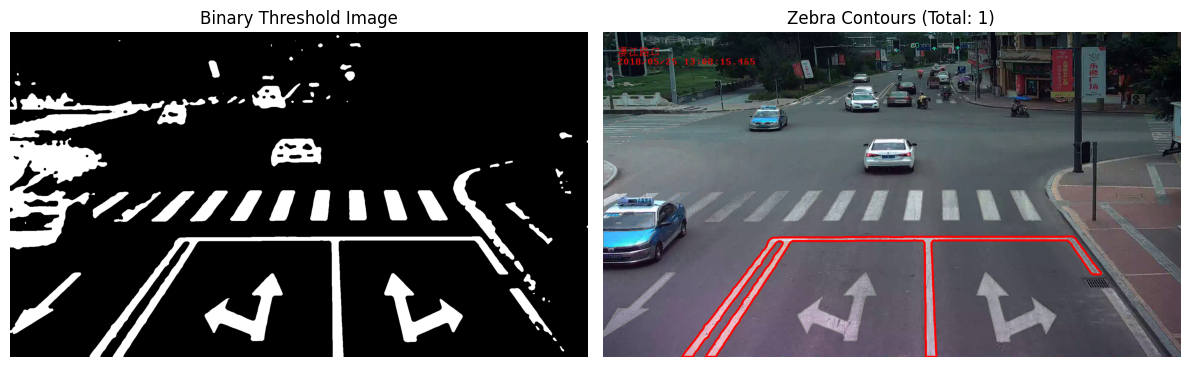

In [5]:
contours, hierarchy = cv2.findContours(
    threshold,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if len(non_zero_indices) > 0:
    min_line_y = np.max(non_zero_indices)
else:
    min_line_y = 0

filtered_by_y_contours = []
for cnt in contours:
    cnt_ys = cnt[:, 0, 1]
    cnt_min_y = np.min(cnt_ys)
    if cnt_min_y > min_line_y:
        filtered_by_y_contours.append(cnt)

zebra_contours = []
if filtered_by_y_contours:
    contour_areas = [cv2.contourArea(cnt) for cnt in filtered_by_y_contours]
    max_area = max(contour_areas)
    area_threshold = max_area * 0.8
    
    for cnt, area in zip(filtered_by_y_contours, contour_areas):
        if area >= area_threshold:
            zebra_contours.append(cnt)
else:
    print("无符合y坐标条件的轮廓")

draw_img = image.copy()
cv2.drawContours(draw_img, contours, -1, (128, 128, 128), 2)
cv2.drawContours(draw_img, zebra_contours, -1, (0, 0, 255), 5)

target_edges = np.zeros((height, width))
cv2.drawContours(target_edges, zebra_contours, -1, 255, 5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(threshold, cmap='gray')
ax1.set_title('Binary Threshold Image')
ax1.axis('off')

ax2.imshow(cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB))
ax2.set_title(f'Zebra Contours (Total: {len(zebra_contours)})')
ax2.set_xlabel('Green: Zebra | Gray: All Contours')
ax2.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# 我们假设最下面一定是我们的车道来源
pts = np.array(zebra_contours[0]).astype(np.uint32)[:,0,:]
x, y = pts[:,0], pts[:,1]

ptlst = pts.tolist()
# print(ptlst)
x_min, x_max, y_min, y_max = np.min(x), np.max(x), np.min(y), np.max(y)
print(f'发现坐标 {x_min} - {x_max}, {y_min} - {y_max}')

code = -1
if ([int(x_min), int(y_max)] in ptlst):
    code = 0
    print(f'发现左下角')
if ([int(x_max), int(y_max)] in ptlst):
    code = 1
    print(f'发现右下角')
if code == -1:
    raise ValueError('未能检测到有效点')

发现坐标 264 - 1654, 679 - 1079
发现左下角


**局部拟合, 使用梯度下降和 MC 方法**

我们首先确定一个最大的 box 就是我们的 $(x_{min}, y_{min})$ 到 $(x_{max}, y_{max})$ 的矩形框

我们首先确定我们的初始点在哪, 一般来说是左侧的点先被找到

如果是左下角的点被找到, 那我们就顺时针依次确认左、上、右，反之则右、上、左

之后我们确定一个点之后使用极坐标系的射线去拟合, 直接从两侧的方向开始即可, 因为这会是从 0 到 1 所以梯度变化很剧烈

所以我们要给它一个巨大的惩罚项，防止它长时间处在有数据的线上，最后我们在根据这个线附近的邻域进行拟合

我们使用简单的 MAE Loss 即可，但是这是一个 HARD 化的方式，当距离过远的时候我们就无视它, 距离近我们就给他一个负数值，这个值越大越好，这样就可以了

可以用 $ y = ln(x) $ 实现，但是如果不去进行数学优化的话好像如果用 $ y = x $ 好像也可以

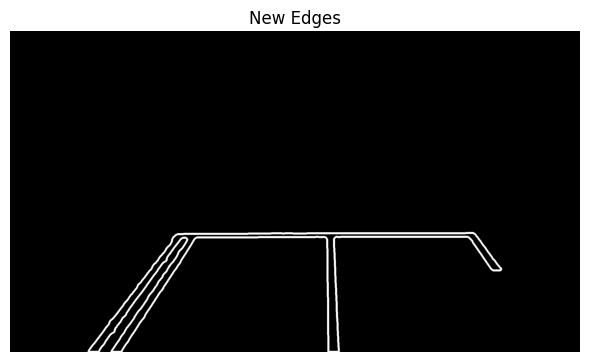

In [7]:
def polar_ray_sample(center, rad, length, min_x=0, min_y=0, max_x=50, max_y=50):
    """
    极坐标系生成射线采样点
    """
    x0, y0 = center
    points = []
    for r in range(0, length):
        x = max(min_x, min(max_x - 1, int(x0 + r * math.cos(rad))))
        y = max(min_y, min(max_y - 1, int(y0 - r * math.sin(rad))))  # 图像y轴向下，sin取负
        points.append((x, y))
    return points

def criterion(x):
    """
    对数计算模式, 越远越没有存在感, 追求平滑所以选择了一个比较大的值
    超过 40 像素后变成加法群幺元， 后续点不再影响本数值
    """
    return min(0, np.log(max(1e-3, np.abs(x)/40)))

def custom_loss(points, edge_img, edge_type:Literal["vertical", "horizontal"]="vertical"):
    """
    自定义的损失函数, 根据最近的点的距离进行判断
    """
    h, w = edge_img.shape
    origin_input = 0
    
    # 垂直方向延伸, 所以比较 width 维度
    if edge_type == "vertical":
        for i in range(height):
            line = edge_img[i, :]
            data_pack = [x for (x,y) in points if y == i]

            ids = np.nonzero(line)[0]
            if len(ids) == 0 or len(data_pack) == 0:
                continue
            origin_input += criterion(np.min(np.abs(ids - data_pack[0])))
    else: # 水平方向延伸, 比较 height 差值
        for i in range(width):
            line = edge_img[:, i]
            data_pack = [y for (x,y) in points if x == i]
                
            ids = np.nonzero(line)[0]
            if len(ids) == 0 or len(data_pack) == 0:
                continue
            origin_input += criterion(np.min(np.abs(ids - data_pack[0])))
        
    return origin_input

def find_edge_intersections(points, edge_img):
    """
    找到射线与边缘的所有交点
    """
    intersections = []
    h, w = edge_img.shape
    for (x, y) in points:
        if x < 0 or x >= w or y < 0 or y >= h:
            continue
        if edge_img[y, x] == 255 and (x, y) not in intersections:
            intersections.append((x, y))
    return intersections

def get_farthest_intersection(intersections, center):
    """
    找到离起点最远的交点
    """
    if len(intersections) == 0:
        return center
    distances = [math.hypot(x - center[0], y - center[1]) for (x, y) in intersections]
    farthest_idx = np.argmax(distances)
    return intersections[farthest_idx]

# line = polar_ray_sample(center=(264, 1079), rad=np.pi/2*(0.58), length=int(np.sqrt(width**2+height**2)+5), max_x=width, max_y=height)
# display(get_farthest_intersection(find_edge_intersections(line, target_edges), center=(264, 1079)))

def least_squares_fit(points):
    """
    最小二乘拟合直线, scipy 直出
    """
    if len(points) < 2:
        raise ValueError("最小二乘法拟合直线至少要有两个点")
    
    x = np.array([p[0] for p in points])
    y = np.array([p[1] for p in points])
    
    if np.std(x) < 1e-6:
        return None, np.mean(x)
    slope, intercept, _, _, _ = stats.linregress(x, y)
    return slope, intercept

# display(least_squares_fit([[1,1],[2,3],[3, 4]]))

def get_ray_line_intersection(ray_center, ray_rad, fit_line):
    """
    计算射线与拟合直线的交点
    """
    x0, y0 = ray_center
    cos_theta = math.cos(ray_rad)
    sin_theta = math.sin(ray_rad) # 点向式直接计算交点
    
    # 拟合直线是垂直直线 x = x_fit
    if fit_line[0] is None:
        x_fit = fit_line[1]
        if cos_theta == 0:  # 射线垂直，无交点
            return (x0, y0)
        t = (x_fit - x0) / cos_theta
        x = int(x_fit)
        y = int(y0 - t * sin_theta)
    # 拟合直线是 y = kx + b
    else:
        k, b = fit_line
        # 联立射线参数方程：x = x0 + t*cosθ, y = y0 - t*sinθ
        denominator = cos_theta + k * sin_theta
        if denominator == 0:  # 平行无交点
            return (x0, y0)
        t = (b - y0 + k * x0) / denominator
        x = int(x0 + t * cos_theta)
        y = int(y0 - t * sin_theta)
    
    return (x, y)

# display(get_ray_line_intersection(ray_center=(0,0), ray_rad=-np.pi/4, fit_line=(0,5)))

new_edges = np.zeros((height, width))
cv2.drawContours(new_edges, zebra_contours, -1, 255, 5)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.imshow(new_edges, cmap='gray')
ax.set_title('New Edges')
ax.axis('off')

plt.tight_layout()
plt.show()

,center,rad,degree,farthest_p
0,"(264, 1079)",0.924703,52.981555,"(564, 680)"


左上点：(564, 680)，左侧边角度：52.98°


,center,rad,degree,farthest_p
0,"(564, 680)",-0.002964,-0.169809,"(1569, 682)"


右上点：(1569, 682)，上侧边角度：-0.17°


,center,rad,degree,farthest_p
0,"(1569, 682)",-0.963281,-55.19195,"(1655, 806)"


右下点：(1655, 806)，右侧边角度：-55.19°


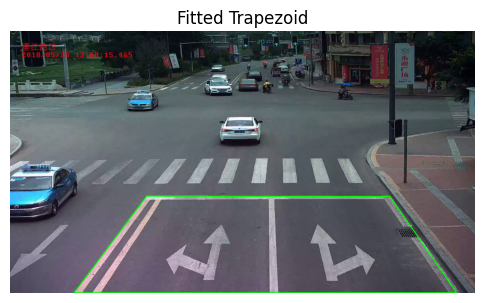

In [8]:
class EarlyStop():
    '''
    提前退出控制类, 用于描述是否有下降
    '''
    def __init__(self,
        bare_rate=20,
        direction:Literal['up', 'down']='down',
        method:Literal['rel', 'abs']='rel'
    ):
        '''
        初始化容忍率和迭代方向
        '''
        self.bare_rate = 20 
        self.direction = direction
        self.method = method
        self.counter = 0

        if direction == 'down':
            self.loss = math.inf
            self.best_loss = math.inf
        elif direction == 'up':
            self.loss = -math.inf
            self.best_loss = -math.inf
        else:
            raise ValueError(f"direction = {direction} 错误")

    def update(self, loss: float):
        '''
        更新迭代, 并且进行判断
        '''
        if self.method == 'rel':
            # 相对变化迭代器, 不用全局最优下降
            if loss < self.loss:
                self.loss = loss
                self.best_loss = loss
                self.counter = 0 # 更新并清除计数器
                return True, 0
            else:
                self.counter += 1
                if self.counter >= self.bare_rate:
                    return False, 2
                return True, 1
                
        elif self.method == 'abs':
            # 绝对变化迭代器, 需要全局最优下降才可以
            if loss < self.best_loss:
                self.best_loss = loss
                self.counter = 0
                return True, 0
            else:
                self.counter += 1
                if self.counter >= self.bare_rate:
                    return False, 2
                return True, 1

def iterative_ray_fitting(center, init_rad, edge_img,
    edge_type: Literal["vertical", "horizontal"],
    length: int = 200,
    init_step: float = 0.05,              # 初始角度步长（弧度）
    decay_rate: float = 0.5,              # 反向时步长衰减系数
    max_iter: int = 50,                   # 最大迭代次数, 基本达不到
    converge_thresh: float = 1e-4         # 收敛阈值
):
    """
    带动态步长衰减的梯形边迭代拟合
    """
    h, w = edge_img.shape
    current_rad = init_rad
    current_step = init_step

    stopper = EarlyStop(bare_rate=20, direction='down', method='rel')
    
    best_loss = custom_loss(
        polar_ray_sample(center, current_rad, int(np.sqrt(w**2+h**2)+5), max_x=w, max_y=h),
        edge_img,
        edge_type
    )
    cond, updated = stopper.update(best_loss)
    # print("第一次确认 best_loss:", best_loss)
    
    best_rad = current_rad
    direction = 'right'
    
    for iter_idx in range(max_iter):
        # 双边收敛
        loss_plus = None
        loss_minus = None

        trigger = True
        
        if direction == 'right':
            new_rad_plus = current_rad - current_step
            points_plus = polar_ray_sample(center, new_rad_plus, length, 0, 0, w, h)
            loss_plus = custom_loss(points_plus, edge_img, edge_type)

            if loss_plus < best_loss:
                best_loss = loss_plus
                best_rad = new_rad_plus
                current_rad = new_rad_plus
                trigger = False

            cond, updated = stopper.update(loss_plus)
            # print(f"{'*' if updated == 0 else ' '}Loss: {loss_plus}, direction: right")
            if not cond:
                print("触发 EarlyStop 准备结算")
                break
                
        elif direction == 'left':
            new_rad_minus = current_rad + current_step
            points_minus = polar_ray_sample(center, new_rad_minus, length, 0, 0, w, h)
            loss_minus = custom_loss(points_minus, edge_img, edge_type)

            if loss_minus < best_loss:
                best_loss = loss_minus
                best_rad = new_rad_minus
                current_rad = new_rad_minus
                trigger = False

            cond, updated = stopper.update(loss_minus)
            # print(f"{'*' if updated == 0 else ' '}Loss: {loss_minus}, direction: left")
            if not cond:
                print("触发 EarlyStop 准备结算")
                break
                
        else:
            raise ValueError(f"方向出现错误: value = {direction}")

        if trigger:
            direction = 'left' if direction == 'right' else 'right'
            current_step *= decay_rate
            if current_step < converge_thresh:
                break
    
    best_points = polar_ray_sample(center, best_rad, int(np.sqrt(w**2+h**2)+5), max_x=w, max_y=h)
    intersections = find_edge_intersections(best_points, edge_img)
    farthest_p = get_farthest_intersection(intersections, center)
    
    display(pd.DataFrame({
        "center": [center],
        "rad": [best_rad],
        "degree": [best_rad/np.pi*180],
        "farthest_p": [farthest_p]
    }))
    
    # edge_cpy = edge_img.copy()
    # fig, ax = plt.subplots(1,1,figsize=(6,4))
    # cv2.circle(edge_cpy, farthest_p, 20, 255, thickness=20)
    # ax.imshow(edge_cpy, cmap='gray')
    # plt.tight_layout()
    # plt.show()
    
    return best_rad, farthest_p, intersections

def fit_trapezoid(center, edge_img,
    code: int,  # 0=左下角开始，1=右下角开始
    x_min: int, x_max: int, y_min: int, y_max: int
):
    """
    完整梯形拟合流程函数
    咱们是靠右行所以就没有写右边的函数
    应该没有井盖或者下水道会修黄线上
    """
    h, w = edge_img.shape
    trapezoid_corners = [center]
    current_center = center
    length_vertical = int(y_max - y_min)  # 垂直边长度
    length_horizontal = int(x_max - x_min)  # 水平边长度
    
    if code == 0:
        '''
        第一步, 从左下角拟合到左上角的直线，由于我们都是要求尽可能多的包含点
        所以我们认为最后的点也在这个范围内, 至少应该在线内
        '''
        init_rad = np.pi/2  # 初始角度90度（向上）
        best_rad_left, left_p, left_inter = iterative_ray_fitting(
            current_center, init_rad, edge_img,
            edge_type="vertical", length=int(np.sqrt(width**2+height**2)+5)
        )
        trapezoid_corners.append(left_p)
        current_center = left_p
        print(f"左上点：{left_p}，左侧边角度：{math.degrees(best_rad_left):.2f}°")
        
        '''
        第二步, 从左上角拟合到右上角的直线
        这一个和其他的评估标准不同, 值得注意
        '''
        init_rad = np.pi/6  # 初始角度三十度（向右）
        best_rad_top, top_p, top_inter = iterative_ray_fitting(
            current_center, init_rad, edge_img,
            edge_type="horizontal", length=length_horizontal
        )
        trapezoid_corners.append(top_p)
        current_center = top_p
        print(f"右上点：{top_p}，上侧边角度：{math.degrees(best_rad_top):.2f}°")
        
        '''
        第三步, 从右上角拟合到右下角的直线
        目前 y = log(x) 对内部的点的要求还是极高的
        短一点也可以满足我们的先验条件
        '''
        init_rad = 0  # 初始角度270度（向下）
        best_rad_right, right_p, right_inter = iterative_ray_fitting(
            current_center, init_rad, edge_img,
            edge_type="vertical", length=length_vertical
        )
        trapezoid_corners.append(right_p)
        print(f"右下点：{right_p}，右侧边角度：{math.degrees(best_rad_right):.2f}°")
    
    return trapezoid_corners

def validate_and_correct_corners(trapezoid_corners, edge_img):
    """
    校验并修正梯形角点，确保右下角点满足x最大/ y最大，且补充绝对最右下角点
    """
    if len(trapezoid_corners) != 4:
        print(f"角点数量异常（{len(trapezoid_corners)}个），直接返回")
        return trapezoid_corners
    
    bottom_left, top_left, top_right, bottom_right = trapezoid_corners
    h, w = edge_img.shape

    corrected_corners = [bottom_left.tolist(), top_left.tolist(), top_right.tolist()]

    x, y = bottom_right[0]
    if x != w-1 and y != h-1:
        xt, yt = top_right[0]
        pre_x = int(x + (h - 1 - y) / ((y - yt) / (x - xt)))
        
        if pre_x > w:
            new_y = int(y + (w - 1 - x) * (y - yt) / (x - xt))
            corrected_corners.append([[w - 1, new_y]])
            corrected_corners.append([[w - 1, h - 1]])
        else:
            corrected_corners.append([[pre_x, h - 1]])
            
    return np.array(corrected_corners, dtype=np.int32)
    

code = 0
x_min, x_max, y_min, y_max = 264, 1654, 679, 1079
center = (x_min, y_max) if code == 0 else (x_max, y_max)

edge_img = new_edges
trapezoid_corners = fit_trapezoid(center, edge_img, code, x_min, x_max, y_min, y_max)

draw_img = image.copy()
trapezoid_pts = np.array(trapezoid_corners, np.int32).reshape((-1, 1, 2))
corrected_corners = validate_and_correct_corners(trapezoid_pts, edge_img)

cv2.polylines(draw_img, [corrected_corners], isClosed=True, color=(0, 255, 0), thickness=3)
plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB))
plt.title("Fitted Trapezoid")
plt.axis("off")
plt.show()

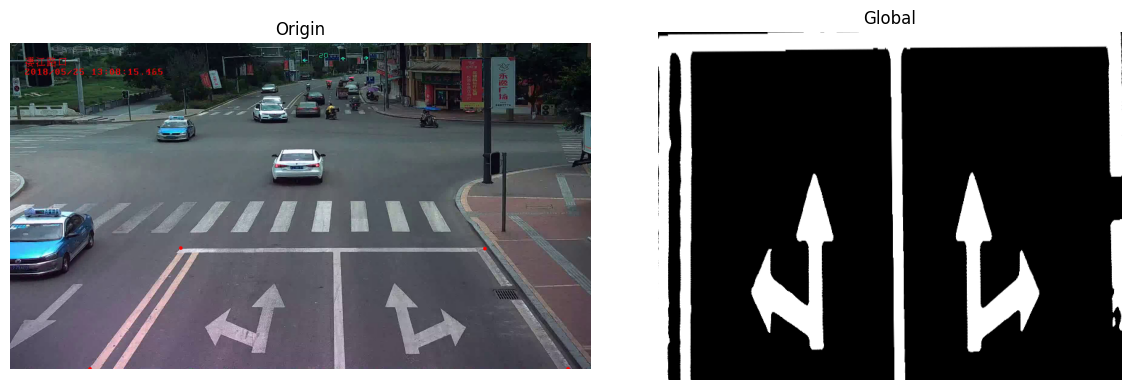

In [9]:
src_pts = np.float32([
    i[0] for i in corrected_corners
])

output_size = (640, 480)
dst_pts = np.float32([
    [0, output_size[1]],
    [0, 0],
    [output_size[0], 0],
    [output_size[0], output_size[1]]
])

H = cv2.getPerspectiveTransform(src_pts, dst_pts)
bird_view = cv2.warpPerspective(threshold, H, output_size)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

temp_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
for (x, y) in src_pts:
    cv2.circle(temp_img, (int(x), int(y)), 6, (255, 0, 0), -1)
ax1.imshow(temp_img)
ax1.set_title('Origin')
ax1.axis('off')

# 俯视变换结果
ax2.imshow(bird_view, cmap='gray')
ax2.set_title('Global')
ax2.axis('off')

plt.tight_layout()
plt.show()

这一步之后**主结构发生变化**，现在变成黑色区域为重点识别区域

然后我们用黑色区域包裹的白色区域为重点识别对象

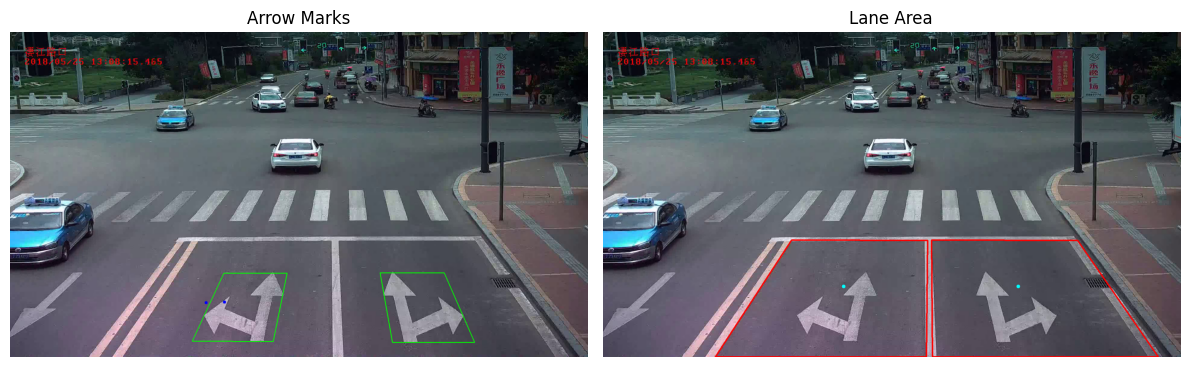

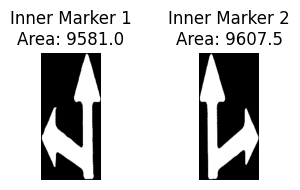

箭头标识信息


,area,area_ratio,center_bird,rect_bird,center_original,rect_original,crop_img,is_valid
0,9581.0,1.0,"(150.81759036982916, 313.4742198100407)","(128, 195, 114, 244)","(712.8634, 897.56573)","[[710.10302734375, 801.2042236328125], [920.69...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",True
1,9607.5,1.0,"(121.75749848208864, 315.88597449908923)","(410, 193, 116, 249)","(651.73206, 899.709)","[[1229.98876953125, 800.4761352539062], [1442....","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",True


车道区域信息


,area,center_bird,rect_bird,center_original,rect_original,contour,is_valid
0,126110.0,"(184.1121150847144, 252.6727658393466)","(44, 21, 283, 459)","(799.0568, 845.541)","[[626.0740356445312, 691.4044799804688], [1078...","[[[296, 21]], [[296, 22]], [[295, 23]], [[212,...",True
1,133414.5,"(483.27867410713725, 251.21732770176155)","(335, 19, 305, 461)","(1379.606, 845.0467)","[[1091.3865966796875, 691.2167358398438], [157...","[[[595, 19]], [[594, 20]], [[418, 20]], [[417,...",True


In [10]:
H_inv = cv2.invert(H)[1] if H is not None else None

bird_view_gray = bird_view
bh, bw = bird_view.shape[:2]
bird_view_bin = cv2.bitwise_not(bird_view_gray)

lane_contours, _ = cv2.findContours(bird_view_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
whole_lane_info_list = []

for cnt in lane_contours:
    area = cv2.contourArea(cnt)
    if area < 0.1 * bh * bw:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = h / w
    if aspect_ratio > 1.0 and aspect_ratio < 6.0:
        
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
        cnt_center_x = M["m10"] / M["m00"]
        cnt_center_y = M["m01"] / M["m00"]
        
        whole_lane_info = {
            "area": area,
            "center_bird": (cnt_center_x, cnt_center_y),
            "rect_bird": (x, y, w, h),
            "center_original": None,
            "rect_original": None,
            "contour": cnt,
            "is_valid": True
        }
        
        if H_inv is not None:
            pt_bird = np.array([[cnt_center_x, cnt_center_y]], dtype=np.float32)
            pt_original = cv2.perspectiveTransform(pt_bird.reshape(-1, 1, 2), H_inv)
            whole_lane_info["center_original"] = (pt_original[0][0][0], pt_original[0][0][1])
            
            rect_pts_bird = np.array([
                [x, y], [x+w, y], [x+w, y+h], [x, y+h]
            ], dtype=np.float32)
            rect_pts_original = cv2.perspectiveTransform(rect_pts_bird.reshape(-1, 1, 2), H_inv)
            whole_lane_info["rect_original"] = rect_pts_original.reshape(4, 2).tolist()
        
        whole_lane_info_list.append(whole_lane_info)

arrow_contours = []
for cnt in lane_contours:
    area = cv2.contourArea(cnt)
    if area < 0.2 * bh * bw:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = h / w
    if aspect_ratio > 1.5 and aspect_ratio < 5:
        arrow_contours.append(cnt)

arrow_contours = sorted(arrow_contours, key=lambda c: cv2.boundingRect(c)[0])

final_arrows = []
lane_info_list = []

for cnt in arrow_contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cropped = bird_view_bin[y:y+h, x:x+w]
    crop_reversed = cv2.bitwise_not(cropped)
    
    inner_contours, _ = cv2.findContours(crop_reversed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not inner_contours:
        continue

    # 最大面积的 0.8 倍筛选
    crop_h, crop_w = crop_reversed.shape[:2]
    min_area = 0.05 * crop_h * crop_w
    valid_contours_with_info = []
    
    for inner_cnt in inner_contours:
        area = cv2.contourArea(inner_cnt)
        if area < min_area:
            continue
        
        M = cv2.moments(inner_cnt)
        if M["m00"] == 0:
            continue
        cnt_center_x = M["m10"] / M["m00"]
        cnt_center_y = M["m01"] / M["m00"]
        
        rect_x = x + cv2.boundingRect(inner_cnt)[0]
        rect_y = y + cv2.boundingRect(inner_cnt)[1]
        rect_w = cv2.boundingRect(inner_cnt)[2]
        rect_h = cv2.boundingRect(inner_cnt)[3]
        
        valid_contours_with_info.append({
            "contour": inner_cnt,
            "area": area,
            "center_bird": (cnt_center_x, cnt_center_y),
            "rect_bird": (rect_x, rect_y, rect_w, rect_h),
            "crop_offset": (x, y)
        })
    
    if len(valid_contours_with_info) == 0:
        continue
    
    max_area = max([item["area"] for item in valid_contours_with_info])
    threshold_area = max_area * 0.8
    filtered_contours = [item for item in valid_contours_with_info if item["area"] >= threshold_area]
    
    for filtered_item in filtered_contours:
        inner_cnt = filtered_item["contour"]
        x_inner, y_inner, w_inner, h_inner = cv2.boundingRect(inner_cnt)
        x_pad = max(0, x_inner - 1)
        y_pad = max(0, y_inner - 1)
        w_pad = min(crop_reversed.shape[1] - x_pad, w_inner + 2)
        h_pad = min(crop_reversed.shape[0] - y_pad, h_inner + 2)
        final_crop = crop_reversed[y_pad:y_pad+h_pad, x_pad:x_pad+w_pad]
        final_arrows.append(final_crop)
        
        lane_info = {
            "area": filtered_item["area"],
            "area_ratio": filtered_item["area"] / max_area,
            "center_bird": filtered_item["center_bird"],
            "rect_bird": filtered_item["rect_bird"],
            "center_original": None,
            "rect_original": None,
            "crop_img": final_crop,
            "is_valid": True
        }
        
        # 计算原图坐标
        if H_inv is not None:
            pt_bird = np.array([[lane_info["center_bird"][0], lane_info["center_bird"][1]]], dtype=np.float32)
            pt_original = cv2.perspectiveTransform(pt_bird.reshape(-1, 1, 2), H_inv)
            lane_info["center_original"] = (pt_original[0][0][0], pt_original[0][0][1])
            
            rect_x, rect_y, rect_w, rect_h = lane_info["rect_bird"]
            rect_pts_bird = np.array([
                [rect_x, rect_y],
                [rect_x + rect_w, rect_y],
                [rect_x + rect_w, rect_y + rect_h],
                [rect_x, rect_y + rect_h]
            ], dtype=np.float32)
            rect_pts_original = cv2.perspectiveTransform(rect_pts_bird.reshape(-1, 1, 2), H_inv)
            lane_info["rect_original"] = rect_pts_original.reshape(4, 2).tolist()
        
        lane_info_list.append(lane_info)

if H_inv is not None and 'image' in locals():
    img_draw_marker = image.copy()
    for info in lane_info_list:
        if info["rect_original"]:
            pts = np.array(info["rect_original"], dtype=np.int32)
            cv2.polylines(img_draw_marker, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
            cv2.circle(img_draw_marker, (int(info["center_original"][0]), int(info["center_original"][1])), 5, (255, 0, 0), -1)
    
    img_draw_lane = image.copy()
    for info in whole_lane_info_list:
        if info["rect_original"]:
            pts = np.array(info["rect_original"], dtype=np.int32)
            cv2.polylines(img_draw_lane, [pts], isClosed=True, color=(0, 0, 255), thickness=3)
            cv2.circle(img_draw_lane, (int(info["center_original"][0]), int(info["center_original"][1])), 6, (255, 255, 0), -1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.imshow(cv2.cvtColor(img_draw_marker, cv2.COLOR_BGR2RGB))
    ax1.set_title("Arrow Marks")
    ax1.axis('off')
    
    ax2.imshow(cv2.cvtColor(img_draw_lane, cv2.COLOR_BGR2RGB))
    ax2.set_title("Lane Area")
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, len(final_arrows), figsize=(2*len(final_arrows), 2))
if len(final_arrows) == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    if i < len(final_arrows):
        ax.imshow(final_arrows[i], cmap='gray')
        ax.set_title(f'Inner Marker {i+1}\nArea: {lane_info_list[i]["area"]:.1f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# 展示数据表格
print("箭头标识信息")
display(pd.DataFrame(lane_info_list))

print("车道区域信息")
display(pd.DataFrame(whole_lane_info_list))

使用设备: cuda:0


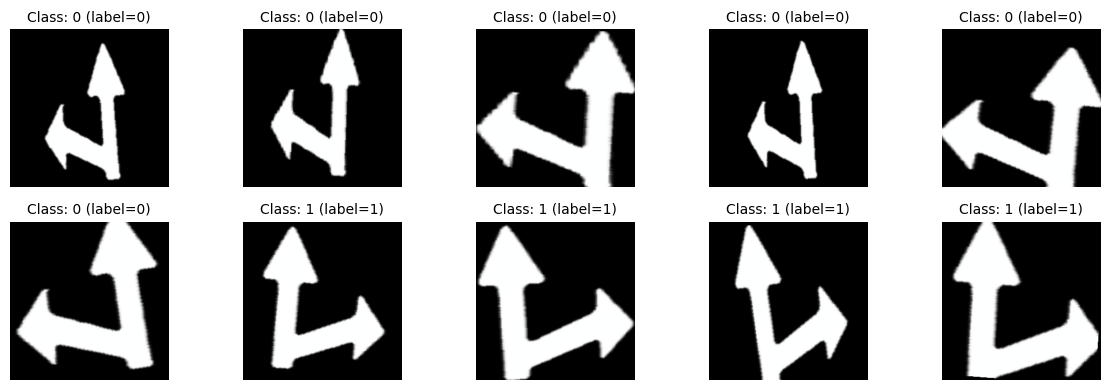

数据集加载完成，共 12 张图片


Train:   0%|          | 0/120 [00:00<?, ?it/s]

In [11]:
BATCH_SIZE = 6
EPOCHS = 120
LR = 1e-5
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {DEVICE}")

NUM_CLASSES = 2
IMG_SIZE = 299
DATA_DIR = "./dataset"

class ArrowDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        适配dataset目录下0、1子文件夹的数据集类
        """
        self.data_dir = data_dir
        self.transform = transform
        self.img_paths = []
        self.labels = []
        self.classes = ["0", "1"]
        self.class_to_idx = {"0": 0, "1": 1}
        
        for cls in self.classes:
            cls_dir = os.path.join(self.data_dir, cls)
            
            if not os.path.exists(cls_dir):
                print(f"警告：类别文件夹 {cls_dir} 不存在，跳过该类别")
                continue
            
            for img_name in os.listdir(cls_dir):
                if not img_name.lower().endswith(".png"):
                    print(f"提示：跳过非png文件 {os.path.join(cls_dir, img_name)}")
                    continue
                
                img_path = os.path.join(cls_dir, img_name)
                self.img_paths.append(img_path)
                self.labels.append(self.class_to_idx[cls])
        
        if len(self.img_paths) == 0:
            raise ValueError(f"错误：在 {self.data_dir} 下未找到任何png图片")

        self.show_samples(n_rows=2, n_cols=5)

    def show_samples(self, n_rows=2, n_cols=5):
        """
        创建2*5的图片展示框，展示经过transform后的图片并标注类别
        """
        max_show = n_rows * n_cols
        show_num = min(max_show, len(self.img_paths))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4))
        axes = axes.flatten()
        
        for i in range(show_num):
            img_tensor, label = self[i]
            
            mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
            std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
            img_np = img_tensor.cpu().numpy() * std + mean
            img_np = np.transpose(img_np, (1, 2, 0))
            img_np = np.clip(img_np, 0, 1)
            
            axes[i].imshow(img_np)
            axes[i].set_title(f"Class: {self.classes[label]} (label={label})", fontsize=10)
            axes[i].axis('off')
        
        for i in range(show_num, n_rows * n_cols):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        label = self.labels[idx]
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"图片读取失败：{img_path}（可能文件损坏或路径错误）")
        
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet均值
                         std=[0.229, 0.224, 0.225])   # ImageNet方差
])

dataset = ArrowDataset(DATA_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"数据集加载完成，共 {len(dataset)} 张图片")

def get_inception_model(num_classes):
    '''
    由于分类任务特殊, 所以这次必须全调
    '''
    weights = Inception_V3_Weights.DEFAULT
    model = models.inception_v3(weights=weights)

    # 迁移训练参数冻结
    # for param in model.parameters():
    #     param.requires_grad = False
    
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    model.AuxLogits.fc = nn.Linear(768, num_classes)
    
    model = model.to(DEVICE)
    return model

# 初始化模型
model = get_inception_model(NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

def train_model(model, dataloader, criterion, optimizer, epochs):
    model.train()
    train_losses = []
    
    global_pbar = tqdm(range(epochs), desc="Train", leave=True)
    
    for epoch in global_pbar:
        epoch_loss = 0.0
        for batch_idx, (inputs, labels) in enumerate(dataloader):
            optimizer.zero_grad()
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs, aux_outputs = model(inputs)
            loss_main = criterion(outputs, labels)
            loss_aux = criterion(aux_outputs, labels)
            loss = loss_main + 0.4 * loss_aux
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)
        
        epoch_loss = epoch_loss / len(dataloader.dataset)
        train_losses.append(epoch_loss)
        global_pbar.set_postfix({"epoch_loss": f"{epoch_loss:.4f}"})
    
    global_pbar.close()
    return model, train_losses

def validate_model(model, dataloader):
    """
    训练完成后，用训练集做一次完整验证，返回最终预测结果
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        val_pbar = tqdm(dataloader, desc="Valid", leave=True)
        for inputs, labels in val_pbar:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model(inputs)
            # 历史遗留问题, 根据库版本进行适配
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    
    return all_preds, all_labels

trained_model, train_losses = train_model(
    model, dataloader, criterion, optimizer, EPOCHS
)

Valid:   0%|          | 0/2 [00:00<?, ?it/s]


整体准确率：1.0000

分类报告：
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     1.0000    1.0000    1.0000         6

    accuracy                         1.0000        12
   macro avg     1.0000    1.0000    1.0000        12
weighted avg     1.0000    1.0000    1.0000        12


混淆矩阵：
[[6 0]
 [0 6]]


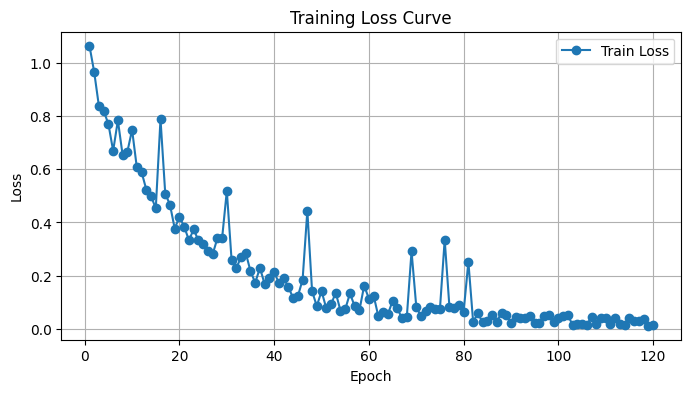


模型已保存为：inception_arrow_model.pth


In [12]:
final_preds, final_labels = validate_model(trained_model, val_dataloader)

accuracy = accuracy_score(final_labels, final_preds)
print(f"\n整体准确率：{accuracy:.4f}")

class_names = dataset.classes
try:
    report = classification_report(
        final_labels, final_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
    print("\n分类报告：")
    print(report)
except Exception as e:
    print(f"\n分类报告生成失败：{e}")

cm = confusion_matrix(final_labels, final_preds)
print("\n混淆矩阵：")
print(cm)

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', label='Train Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

torch.save(trained_model.state_dict(), "inception_arrow_model.pth")
print("\n模型已保存为：inception_arrow_model.pth")

**p.s.**

经过 CV 处理后的二值化图案，**极大地降低了模型的泛化难度**，让它更容易学到真正的特征

不过值得注意的是，对该类任务泛化的难度并未消失，**只是转移到了你前置的 CV 算法内**

In [13]:
@torch.no_grad()
def run_inception_predict(inception_model, final_arrows, class_names=["左前", "右前"], verbose=True):
    """
    用加载好的Inception模型预测裁剪后的箭头图片
    """
    if len(final_arrows) == 0:
        print("警告：输入的箭头图片列表为空！")
        return [], []
    
    input_tensors = []
    for idx, img in enumerate(final_arrows):
        if img is None or len(img.shape) == 0:
            print(f"警告：第{idx}张图片无效，跳过")
            continue
        if len(img.shape) == 2:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img_rgb = img
        
        img_tensor = transform(img_rgb)
        input_tensors.append(img_tensor)
    
    if len(input_tensors) == 0:
        print("警告：无有效图片可预测！")
        return [], []
    
    batch_tensor = torch.stack(input_tensors).to(DEVICE)
    
    outputs = inception_model(batch_tensor)
    if isinstance(outputs, tuple):
        outputs = outputs[0]
    
    preds_probs = torch.softmax(outputs, dim=1)
    preds_idx = torch.argmax(preds_probs, dim=1).cpu().numpy()
    preds_conf = preds_probs[range(len(preds_idx)), preds_idx].cpu().numpy()
    
    if verbose:
        for idx, (pred_idx, pred_conf) in enumerate(zip(preds_idx, preds_conf)):
            pred_name = class_names[pred_idx]
            print(f"箭头图片 {idx+1}：预测类别={pred_name} (索引={pred_idx})，置信度={pred_conf:.4f}")
    
    return preds_idx, preds_conf

inception_model = get_inception_model(NUM_CLASSES)
inception_model.load_state_dict(torch.load("inception_arrow_model.pth", weights_only=True, map_location=DEVICE))

preds_idx, preds_conf = run_inception_predict(inception_model, final_arrows)

箭头图片 1：预测类别=左前 (索引=0)，置信度=0.9946
箭头图片 2：预测类别=右前 (索引=1)，置信度=0.9746


,area,center_bird,rect_bird,center_original,rect_original,contour,is_valid,pred_idx,pred_conf,mask_value
0,126110.0,"(184.1121150847144, 252.6727658393466)","(44, 21, 283, 459)","(799.0568, 845.541)","[[626.0740356445312, 691.4044799804688], [1078...","[[[296, 21]], [[296, 22]], [[295, 23]], [[212,...",True,0,0.994587,1
1,133414.5,"(483.27867410713725, 251.21732770176155)","(335, 19, 305, 461)","(1379.606, 845.0467)","[[1091.3865966796875, 691.2167358398438], [157...","[[[595, 19]], [[594, 20]], [[418, 20]], [[417,...",True,1,0.974554,2


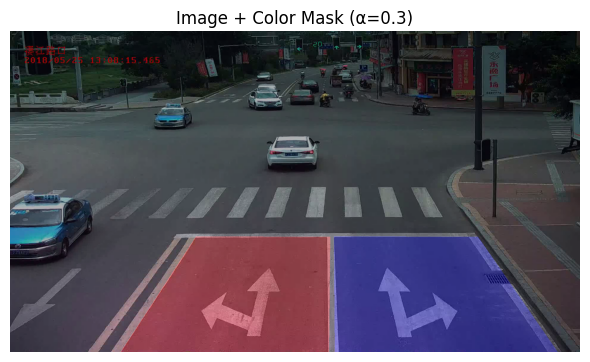

In [14]:
mask_idx_map = {
    0: 1, 
    1: 2
}

color_map = {
    0: (0, 0, 0),
    1: (0, 0, 255),
    2: (255, 0, 0)
}

for i, lane_info in enumerate(lane_info_list):
    if i < len(preds_idx):
        lane_info["pred_idx"] = preds_idx[i]
        lane_info["pred_conf"] = preds_conf[i]
        lane_info["mask_value"] = mask_idx_map.get(preds_idx[i], 0)

whole_lane_info_list_sorted = sorted(
    whole_lane_info_list,
    key=lambda x: x["center_original"][0] if (x["center_original"] and len(x["center_original"]) > 0) else 0
)
for i, lane_info in enumerate(whole_lane_info_list_sorted):
    if i < len(preds_idx):
        lane_info["pred_idx"] = preds_idx[i]
        lane_info["pred_conf"] = preds_conf[i]
        lane_info["mask_value"] = mask_idx_map.get(preds_idx[i], 0)

display(pd.DataFrame(whole_lane_info_list_sorted))

if H_inv is not None and 'image' in locals():
    lane_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    
    for lane_info in whole_lane_info_list_sorted:
        if lane_info.get("rect_original") and lane_info.get("mask_value", 0) > 0:
            rect_pts = np.array(lane_info["rect_original"], dtype=np.int32)
            cv2.fillPoly(lane_mask, [rect_pts], color=lane_info["mask_value"])

    mask_color = np.zeros((lane_mask.shape[0], lane_mask.shape[1], 3), dtype=np.uint8)
    for val in [1, 2]:
        mask_color[lane_mask == val] = color_map[val]
    
    alpha = 0.3
    img_overlay = cv2.addWeighted(image, 1-alpha, mask_color, alpha, 0)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    ax.imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Image + Color Mask (α={alpha})", fontsize=12)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()